# 🇰🇷 실습: 대한민국 공공데이터 활용 3D 도시 모델링

이 노트북은 **국토정보플랫폼**이나 **국가공간정보포털**에서 수집한 국내 공공데이터(건물높이DB 등)를 사용하여 VoxCity 모델을 생성하는 실습 가이드입니다.

## 📋 학습 내용
1. ✅ 로컬 SHP/GeoPackage 데이터 로드
2. ✅ 좌표계 변환 (EPSG:5179 → EPSG:4326)
3. ✅ 높이 데이터 정규화 (`height` 컬럼 생성)
4. ✅ VoxCity 모델 생성 및 시각화

## 📦 1. 환경 준비 및 라이브러리 임포트

In [1]:
import os
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
from voxcity.generator import get_voxcity
from voxcity.visualizer.renderer import visualize_voxcity_plotly

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 🛠️ 2. 실습용 데이터 준비 (Mock Data 생성)

실제 공공데이터 파일이 없는 경우를 위해, 서울 시청 인근의 건물 데이터를 모사한 가상의 데이터를 생성합니다.
이미 수집한 `.shp` 파일이 있다면 이 단계를 건너뛰고 3단계에서 직접 파일을 로드하세요.

In [2]:
# 실습용 가상 건물 데이터 생성 (서울 시청 인근)
def create_mock_korea_data():
    # 서울 시청 부근 폴리곤
    coords = [
        (126.977, 37.566), (126.977, 37.567), 
        (126.978, 37.567), (126.978, 37.566)
    ]
    poly = Polygon(coords)
    
    # GeoDataFrame 생성 (국내 표준 좌표계 EPSG:5179 가정)
    gdf = gpd.GeoDataFrame({
        'geometry': [poly],
        'BLDH_BV': [25.5],  # 건물높이DB의 속성명 모사
        'GRO_FLO_CO': [7]    # 건물통합정보의 층수 데이터 모사
    }, crs="EPSG:4326").to_crs(epsg=5179) 
    
    return gdf

korea_buildings = create_mock_korea_data()
print("실습용 데이터 생성 완료 (좌표계: ", korea_buildings.crs, ")")
korea_buildings.head()

실습용 데이터 생성 완료 (좌표계:  EPSG:5179 )


,geometry,BLDH_BV,GRO_FLO_CO
0,"POLYGON ((953812.544 1951977.099, 953813.161 1...",25.5,7


## 🔄 3. 데이터 전처리 (좌표계 및 속성명)

공공데이터를 VoxCity에서 사용하기 위해 **EPSG:4326**으로 변환하고, 높이 컬럼명을 `height`로 통일합니다.

In [3]:
# 1. 좌표계 변환 (WGS84로 통일)
if korea_buildings.crs != "EPSG:4326":
    print("좌표계 변환 수행: ", korea_buildings.crs, " -> EPSG:4326")
    korea_buildings = korea_buildings.to_crs(epsg=4326)

# 2. 높이 속성 정규화
if 'BLDH_BV' in korea_buildings.columns:
    # 건물높이DB 사용 시
    korea_buildings = korea_buildings.rename(columns={'BLDH_BV': 'height'})
    print("건물높이DB 속성(BLDH_BV)을 'height'로 매핑 완료")
elif 'GRO_FLO_CO' in korea_buildings.columns:
    # 건물통합정보(층수) 사용 시
    korea_buildings['height'] = korea_buildings['GRO_FLO_CO'] * 3.3
    print("층수 데이터를 기반으로 'height' 추정 완료")

korea_buildings.head()

좌표계 변환 수행:  EPSG:5179  -> EPSG:4326
건물높이DB 속성(BLDH_BV)을 'height'로 매핑 완료


,geometry,height,GRO_FLO_CO
0,"POLYGON ((126.977 37.566, 126.977 37.567, 126....",25.5,7


## 🚀 4. VoxCity 모델 생성

준비된 데이터를 `building_gdf` 파라미터로 전달하여 3D 모델을 생성합니다.

INFO | voxcity.voxcity.generator.api | Auto-selecting data sources for: building_source, canopy_height_source, building_complementary_source


Loading formatted geocoded file...


INFO | voxcity.voxcity.generator.api | Detected country for ROI center (126.9775, 37.5665): Korea, Republic of
INFO | voxcity.voxcity.generator.api | Selected data sources:
INFO | voxcity.voxcity.generator.api | - Buildings(base)=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Buildings(comp)=None
INFO | voxcity.voxcity.generator.api | - LandCover=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Canopy=High Resolution 1m Global Canopy Height Maps | https://gee-community-catalog.org/projects/meta_trees/
INFO | voxcity.voxcity.generator.api | - DEM=Flat
INFO | voxcity.voxcity.generator.api | - ComplementHeight=10
INFO | voxcity.voxcity.generator.grids | Creating Land Use Land Cover grid
 
INFO | voxcity.voxcity.generator.grids | Data source: OpenStreetMap
INFO | voxcity.voxcity.generator.grids | 
OpenStreetMap Land Cover Classes (source-specific, 0-based indices):
------------------------------------------------

Fetching data from Overpass API...
Converting data to GeoJSON format...


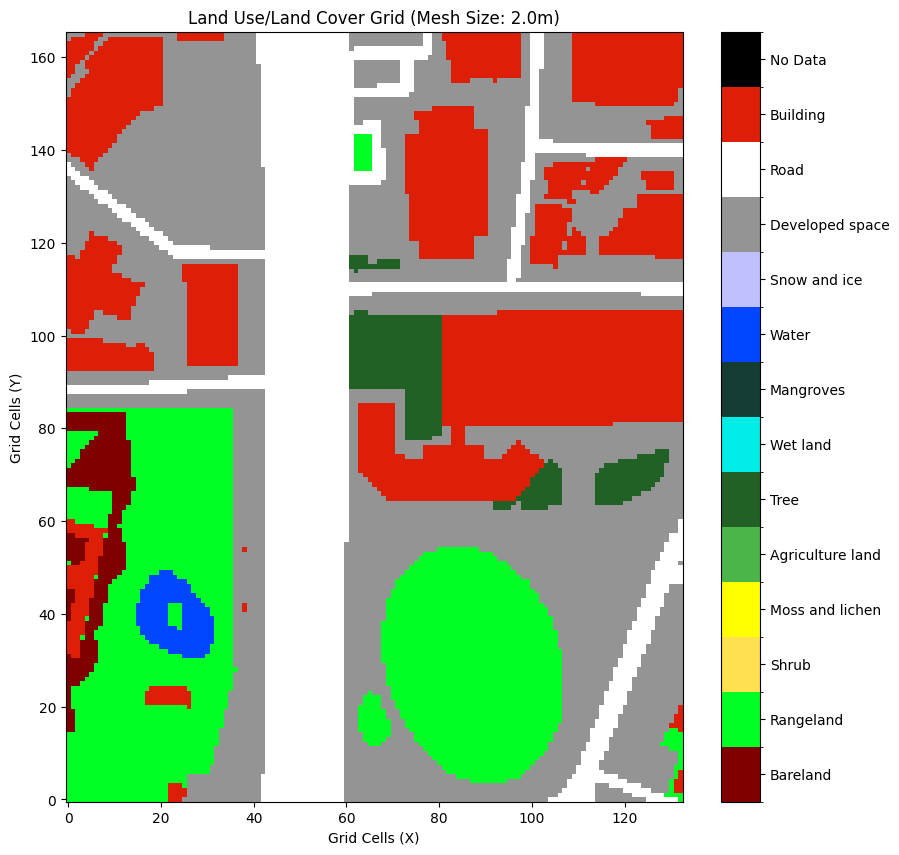

INFO | voxcity.voxcity.generator.grids | Creating Building Height grid
 
INFO | voxcity.voxcity.generator.grids | Base data source: OpenStreetMap
INFO | voxcity.voxcity.generator.grids | Using provided GeoDataFrame for building data
INFO | voxcity.voxcity.generator.grids | Complementary data source: None
INFO | voxcity.voxcity.geoprocessor.raster.buildings | 0 of the total 1 building footprint from the base data source did not have height data.


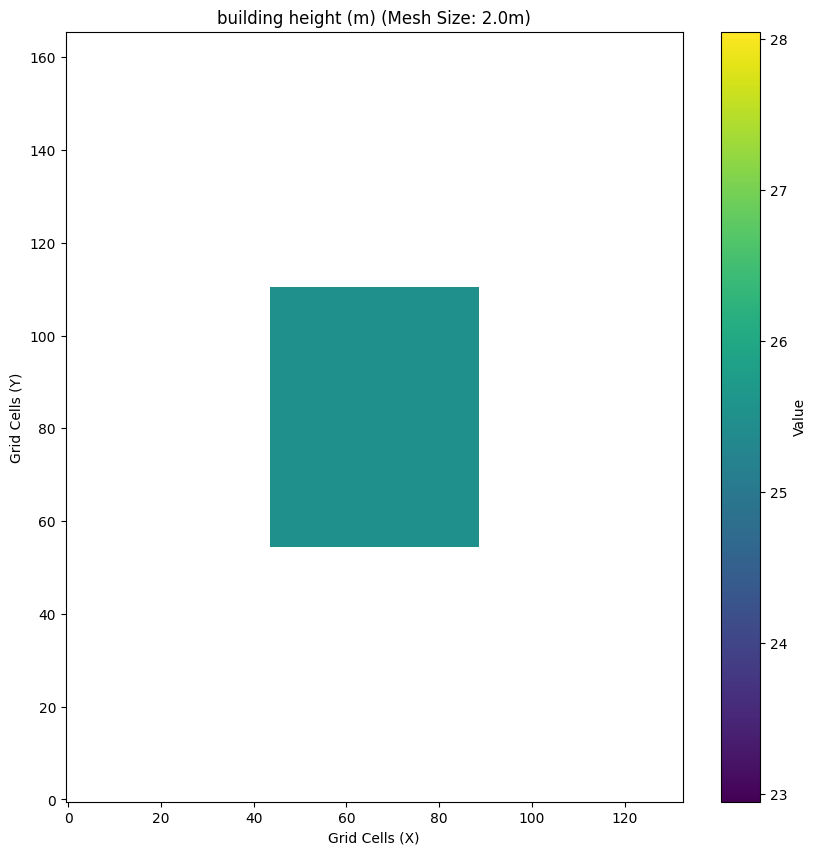

INFO | voxcity.voxcity.generator.grids | Creating Canopy Height grid
 
INFO | voxcity.voxcity.generator.grids | Data source: High Resolution 1m Global Canopy Height Maps


Generating URL ...
Please wait ...
Data downloaded to D:\repository\VoxCity\docs\examples\output\canopy_height.tif


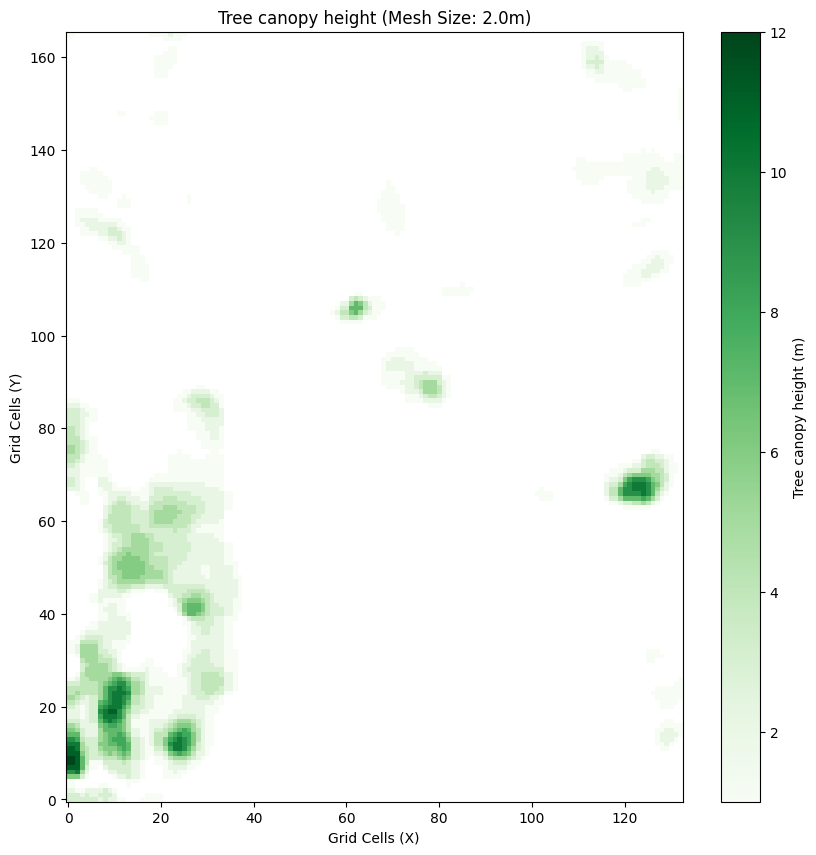

INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water              - Water bodies
  10: Snow and ice       - Snow, ice, glaciers
  11: Developed space    - Urban areas, parking
  12: Road               - Roads, p

VoxCity results saved to output/voxcity.h5
VoxCity 모델 생성 완료


In [4]:
# 관심 영역 정의 (전처리된 데이터의 경계 기준)
bounds = korea_buildings.total_bounds
rectangle_vertices = [
    (bounds[0] - 0.001, bounds[1] - 0.001), # SW
    (bounds[0] - 0.001, bounds[3] + 0.001), # NW
    (bounds[2] + 0.001, bounds[3] + 0.001), # NE
    (bounds[2] + 0.001, bounds[1] - 0.001)  # SE
]

# 모델 생성 (지형 및 토지피복은 OSM/GEE 데이터 활용)
city = get_voxcity(
    rectangle_vertices,
    meshsize=2.0,           # 공공데이터 활용을 위해 2m 해상도 설정
    building_gdf=korea_buildings,
    land_cover_source='OpenStreetMap',
    dem_source='Flat',      # 실습을 위해 평탄 지형 설정
    **{"gridvis": True}
)

print("VoxCity 모델 생성 완료")

## 👁️ 5. 3D 시각화

생성된 대한민국 도시 모델을 Plotly를 통해 대화형으로 확인합니다.

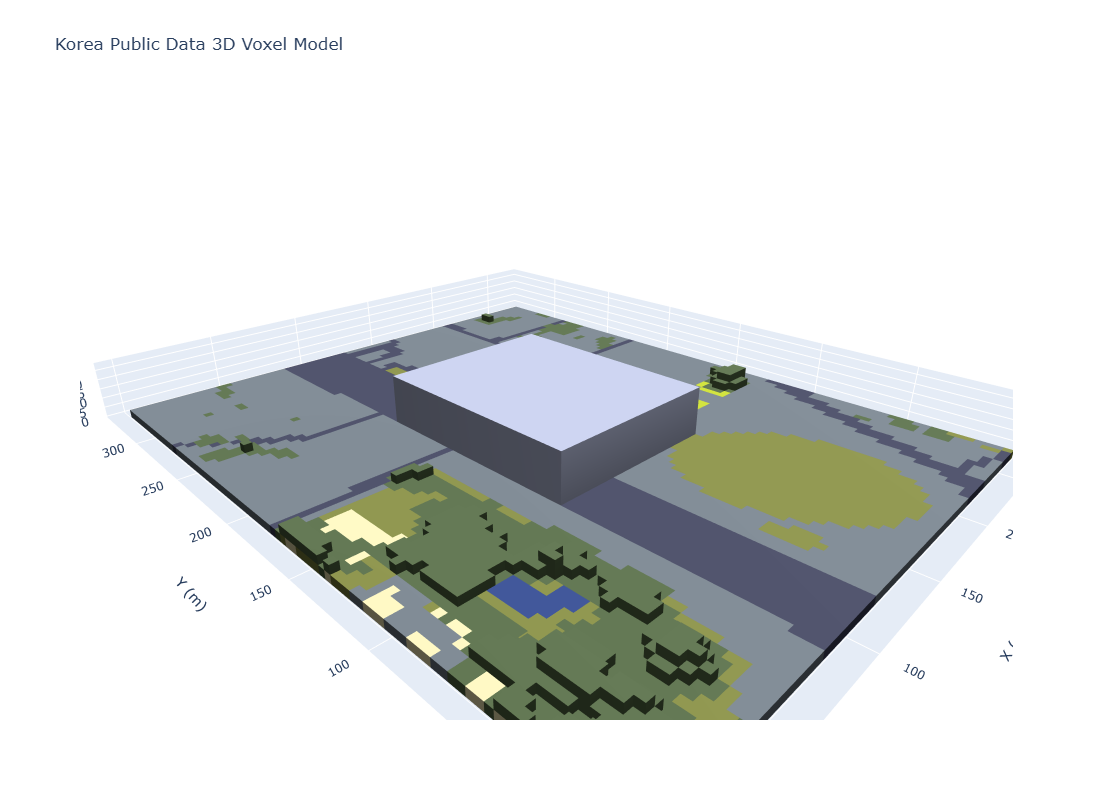

In [6]:
visualize_voxcity_plotly(
    city.voxels.classes,
    city.voxels.meta.meshsize,
    title="Korea Public Data 3D Voxel Model"
)

## 💾 6. 모델 내보내기

분석된 결과를 외부 3D 소프트웨어에서 사용할 수 있도록 OBJ 형식으로 저장합니다.

In [7]:
from voxcity.exporter.obj import export_obj

output_dir = "output/korea_demo"
export_obj(city, output_dir, "seoul_city_model")

print(f"모델 저장 완료: {output_dir}/seoul_city_model.obj")

INFO | voxcity.voxcity.exporter.obj | OBJ and MTL files have been generated in output/korea_demo with the base name "seoul_city_model".


모델 저장 완료: output/korea_demo/seoul_city_model.obj
